# Day 3 — Cross-Subject Validation

## Why this matters more than accuracy

Our current evaluation splits epochs randomly.
This means Subject 7's epoch 100 might be in training
and Subject 7's epoch 101 in test.

The model has already "seen" Subject 7's brain patterns.
This inflates performance — sometimes by 5-10%.

Leave-One-Subject-Out (LOSO) validation:
- Train on subjects 1-19, test on subject 20
- Train on subjects 1-18 + 20, test on subject 19
- Repeat 20 times
- Average = true generalisation to NEW people

This is what clinical deployment actually requires.
A sleep staging system must work on someone it has
never seen before.

## Why this is the publishable metric
Every serious sleep staging paper reports LOSO.
If we only report random split — reviewers will ask
for LOSO in the revision. Better to run it now.

In [1]:
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report,
                              cohen_kappa_score,
                              confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from datetime import datetime

PROJECT_ROOT  = (r"C:\Users\Hp\.vscode\PROJECT 07"
                 r"\classifier_main_pipeline")
PROCESSED_DIR = os.path.join(PROJECT_ROOT,
                              "data", "processed")
MODELS_DIR    = os.path.join(PROJECT_ROOT, "models")
PLOTS_DIR     = os.path.join(PROJECT_ROOT, "plots")
LOGS_DIR      = os.path.join(PROJECT_ROOT, "logs")

sys.path.append(os.path.join(PROJECT_ROOT, "src"))
os.makedirs(MODELS_DIR, exist_ok=True)

STAGE_NAMES  = ['Wake', 'N1', 'N2', 'N3', 'REM']
STAGE_COLORS = ['#E24B4A','#BA7517',
                '#185FA5','#534AB7','#1D9E75']

print(" Setup ready")

 Setup ready


In [2]:
import mne

DATA_DIR = os.path.join(PROJECT_ROOT,
                         "data", "physionet-sleep-data")

all_files = os.listdir(DATA_DIR)
psg_files = sorted([f for f in all_files
                     if f.endswith('-PSG.edf')])
hyp_files = sorted([f for f in all_files
                     if 'Hypnogram' in f
                     and f.endswith('.edf')])

# Match pairs
pairs = []
for psg in psg_files:
    subj_id = psg[:6]
    match   = [h for h in hyp_files
                if h.startswith(subj_id)]
    if match:
        pairs.append((
            os.path.join(DATA_DIR, psg),
            os.path.join(DATA_DIR, match[0]),
            subj_id
        ))

print(f"Found {len(pairs)} subject pairs")

STAGE_MAP = {
    'Sleep stage W': 0, 'Sleep stage 1': 1,
    'Sleep stage 2': 2, 'Sleep stage 3': 3,
    'Sleep stage 4': 3, 'Sleep stage R': 4,
}
EPOCH_LEN   = 30
EEG_CHANNEL = "EEG Fpz-Cz"
LOW_FREQ    = 0.3
HIGH_FREQ   = 35


def load_subject(psg_path, hyp_path):
    """Load one subject's epochs and labels."""
    try:
        raw = mne.io.read_raw_edf(
            psg_path, preload=True, verbose=False)

        if EEG_CHANNEL not in raw.ch_names:
            return None, None

        raw.pick_channels([EEG_CHANNEL])
        raw.filter(LOW_FREQ, HIGH_FREQ, verbose=False)

        sfreq   = raw.info['sfreq']
        spe     = int(EPOCH_LEN * sfreq)
        signal  = raw.get_data()[0]
        ann     = mne.read_annotations(hyp_path)
        raw.set_annotations(ann, verbose=False)

        labels = []
        for a in raw.annotations:
            stage = a['description']
            dur   = a['duration']
            if stage in STAGE_MAP:
                labels.extend(
                    [STAGE_MAP[stage]] * int(dur/EPOCH_LEN)
                )

        labels = np.array(labels)
        n      = len(signal) // spe
        signal = signal[:n * spe]
        epochs = signal.reshape(n, spe)

        mn = min(len(epochs), len(labels))
        epochs, labels = epochs[:mn], labels[:mn]

        # Cropping to sleep period
        nw = np.where(labels != 0)[0]
        if len(nw) == 0:
            return None, None

        epochs = epochs[nw[0]:nw[-1]+1]
        labels = labels[nw[0]:nw[-1]+1]

        return epochs.astype(np.float32), labels

    except Exception as e:
        return None, None


# Loading all subjects
print("Loading subjects...")
subject_data = []

for psg_path, hyp_path, subj_id in pairs:
    epochs, labels = load_subject(psg_path, hyp_path)
    if epochs is not None:
        subject_data.append({
            'id':     subj_id,
            'epochs': epochs,
            'labels': labels,
            'n':      len(labels)
        })
        print(f"   {subj_id}: {len(labels)} epochs")
    else:
        print(f"    {subj_id}: failed")

print(f"\nLoaded {len(subject_data)} subjects")

Found 20 subject pairs
Loading subjects...


C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:55: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(ann, verbose=False)
C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(


   SC4001: 721 epochs
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


...

C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:55: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(ann, verbose=False)
C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(


   SC4171: 882 epochs
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:55: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(ann, verbose=False)
C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:42: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(


   SC4181: 844 epochs
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
   SC4191: 1415 epochs

Loaded 20 subjects


C:\Users\Hp\AppData\Local\Temp\ipykernel_15704\3645336080.py:55: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(ann, verbose=False)


In [3]:
class CNNLSTMSleepClassifier(nn.Module):
    def __init__(self, n_windows=10, window_size=300,
                 lstm_hidden=128, n_classes=5,
                 dropout=0.3):
        super().__init__()
        self.n_windows   = n_windows
        self.window_size = window_size
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, 5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.lstm = nn.LSTM(
            128, lstm_hidden, 2,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        batch = x.shape[0]
        x     = x.reshape(batch, self.n_windows,
                           self.window_size)
        feats = []
        for t in range(self.n_windows):
            w = x[:, t, :].unsqueeze(1)
            f = self.cnn(w).squeeze(-1)
            feats.append(f)
        seq    = torch.stack(feats, dim=1)
        out, _ = self.lstm(seq)
        last   = out[:, -1, :]
        return self.classifier(last)


class RawEEGDataset(Dataset):
    def __init__(self, epochs, labels):
        mean = epochs.mean(axis=1, keepdims=True)
        std  = epochs.std(axis=1,  keepdims=True) + 1e-8
        self.X = ((epochs - mean) / std).astype(np.float32)
        self.y = labels.astype(np.int64)

    def __len__(self):  return len(self.X)

    def __getitem__(self, i):
        return torch.FloatTensor(self.X[i]), self.y[i]


print(" Model and Dataset defined")

 Model and Dataset defined


In [4]:
def train_one_fold(train_data, test_data,
                   epochs=30, batch_size=64):
    """
    Train on all subjects except one,
    test on the left-out subject.
    """
    # Combining training subjects
    X_tr = np.concatenate(
        [d['epochs'] for d in train_data])
    y_tr = np.concatenate(
        [d['labels'] for d in train_data])
    X_te = test_data['epochs']
    y_te = test_data['labels']

    # DataLoaders
    train_loader = DataLoader(
        RawEEGDataset(X_tr, y_tr),
        batch_size=batch_size,
        shuffle=True, num_workers=0
    )
    test_loader = DataLoader(
        RawEEGDataset(X_te, y_te),
        batch_size=128,
        shuffle=False, num_workers=0
    )

    # Model + optimiser
    model     = CNNLSTMSleepClassifier()
    weights   = compute_class_weight(
        'balanced',
        classes=np.unique(y_tr), y=y_tr
    )
    criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(weights))
    optimizer = torch.optim.Adam(
        model.parameters(), lr=0.001,
        weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max',
        patience=3, factor=0.5
    )

    best_acc   = 0
    best_preds = None
    best_state = None

    for epoch in range(epochs):
        # Train
        model.train()
        for X, y in train_loader:
            optimizer.zero_grad()
            out  = model(X)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0)
            optimizer.step()

        # Evaluation
        model.eval()
        preds, true = [], []
        with torch.no_grad():
            for X, y in test_loader:
                p = model(X).argmax(1)
                preds.extend(p.numpy())
                true.extend(y.numpy())

        preds = np.array(preds)
        true  = np.array(true)
        acc   = (preds == true).mean()
        scheduler.step(acc)

        if acc > best_acc:
            best_acc   = acc
            best_preds = preds
            best_true  = true

    return best_preds, best_true, best_acc


# ── Running LOSO ──────────────────────────────────────────────
print("Running Leave-One-Subject-Out validation...")
print(f"{'Fold':>5} {'Subject':>10} "
      f"{'Accuracy':>10} {'Kappa':>8}")
print("-" * 40)

fold_results = []
all_preds    = []
all_true     = []

for i, test_subj in enumerate(subject_data):
    train_subjs = [s for j, s in enumerate(subject_data)
                   if j != i]

    preds, true, acc = train_one_fold(
        train_subjs, test_subj, epochs=20
    )

    kappa = cohen_kappa_score(true, preds)
    fold_results.append({
        'subject':  test_subj['id'],
        'accuracy': acc,
        'kappa':    kappa,
        'n':        test_subj['n']
    })
    all_preds.extend(preds)
    all_true.extend(true)

    print(f"{i+1:>5} {test_subj['id']:>10} "
          f"{acc:>10.4f} {kappa:>8.4f}")

print("-" * 40)

# ── Aggregate results ──────────────────────────────────────
all_preds = np.array(all_preds)
all_true  = np.array(all_true)

loso_acc   = (all_preds == all_true).mean()
loso_kappa = cohen_kappa_score(all_true, all_preds)
mean_fold_acc   = np.mean(
    [r['accuracy'] for r in fold_results])
std_fold_acc    = np.std(
    [r['accuracy'] for r in fold_results])
mean_fold_kappa = np.mean(
    [r['kappa'] for r in fold_results])

print(f"\n=== LOSO Results ===\n")
print(f"Overall accuracy:    {loso_acc:.4f}")
print(f"Overall Kappa:       {loso_kappa:.4f}")
print(f"Mean fold accuracy:  "
      f"{mean_fold_acc:.4f} ± {std_fold_acc:.4f}")
print(f"Mean fold Kappa:     {mean_fold_kappa:.4f}")
+++++++++++++++++++9
print(f"\n=== LOSO Classification Report ===\n")
print(classification_report(
    all_true, all_preds,
    target_names=STAGE_NAMES
))

Running Leave-One-Subject-Out validation...
 Fold    Subject   Accuracy    Kappa
----------------------------------------
    1     SC4001     0.8377   0.7823
    2     SC4011     0.8423   0.7551
    3     SC4021     0.7204   0.5805
    4     SC4031     0.7560   0.6263
    5     SC4041     0.7094   0.5666
    6     SC4051     0.8714   0.8263
    7     SC4061     0.8603   0.7884
    8     SC4071     0.8423   0.7671
    9     SC4081     0.8402   0.7886
   10     SC4091     0.6828   0.5001
   11     SC4101     0.7673   0.5805
   12     SC4111     0.4381   0.2227
   13     SC4121     0.7618   0.6426
   14     SC4131     0.8249   0.7432
   15     SC4141     0.8824   0.8270
   16     SC4151     0.8089   0.7304
   17     SC4161     0.7041   0.5841
   18     SC4171     0.7460   0.6394
   19     SC4181     0.7251   0.6120
   20     SC4191     0.8353   0.7408
----------------------------------------

=== LOSO Results ===

Overall accuracy:    0.7717
Overall Kappa:       0.6721
Mean fold accuracy

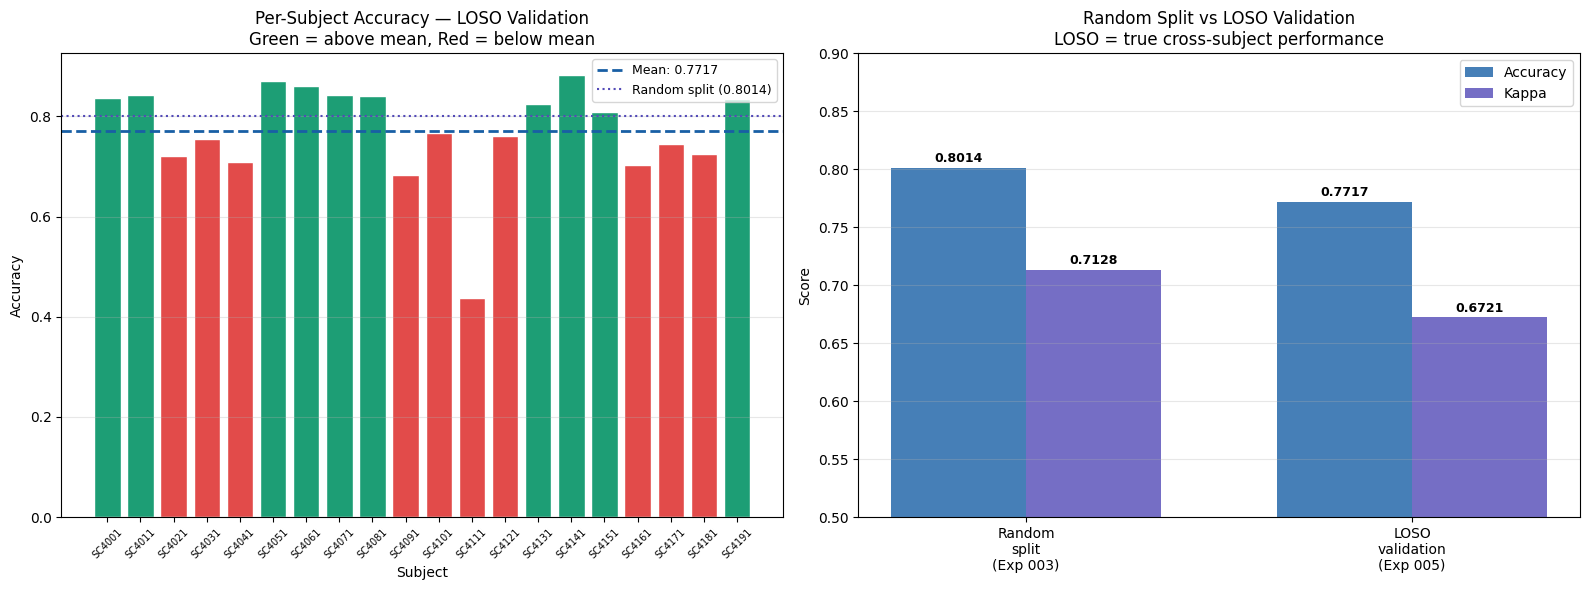

 LOSO plots saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Per-subject accuracy ───────────────────────────────────
subjects  = [r['subject'] for r in fold_results]
accs      = [r['accuracy'] for r in fold_results]
kappas    = [r['kappa'] for r in fold_results]

colors = ['#1D9E75' if a >= loso_acc
          else '#E24B4A' for a in accs]

bars = axes[0].bar(subjects, accs,
                    color=colors, edgecolor='white')
axes[0].axhline(y=loso_acc, color='#185FA5',
                linestyle='--', linewidth=2,
                label=f'Mean: {loso_acc:.4f}')
axes[0].axhline(
    y=0.8014, color='#534AB7',
    linestyle=':', linewidth=1.5,
    label='Random split (0.8014)'
)
axes[0].set_title(
    'Per-Subject Accuracy — LOSO Validation\n'
    'Green = above mean, Red = below mean'
)
axes[0].set_xlabel('Subject')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x',
                     rotation=45, labelsize=7)
axes[0].grid(axis='y', alpha=0.3)

# ── LOSO vs random split comparison ───────────────────────
comparison = {
    'Random\nsplit\n(Exp 003)': {
        'accuracy': 0.8014,
        'kappa':    0.7128
    },
    'LOSO\nvalidation\n(Exp 005)': {
        'accuracy': loso_acc,
        'kappa':    loso_kappa
    }
}

x      = np.arange(2)
w      = 0.35
labels = list(comparison.keys())
accs_c = [comparison[k]['accuracy'] for k in labels]
kaps_c = [comparison[k]['kappa']    for k in labels]

axes[1].bar(x - w/2, accs_c, w,
             label='Accuracy',
             color='#185FA5', alpha=0.8)
axes[1].bar(x + w/2, kaps_c, w,
             label='Kappa',
             color='#534AB7', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=10)
axes[1].set_ylim(0.5, 0.9)
axes[1].set_title(
    'Random Split vs LOSO Validation\n'
    'LOSO = true cross-subject performance'
)
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.4f}',
        ha='center', fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR,
            'exp005_loso_results.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" LOSO plots saved")

In [6]:
results_005 = {
    'experiment':         '005',
    'name':               'LOSO Cross-Subject Validation',
    'date':               datetime.now().strftime('%Y-%m-%d'),
    'validation_method':  'Leave-One-Subject-Out',
    'n_subjects':         len(subject_data),
    'results': {
        'loso_accuracy':    round(float(loso_acc), 4),
        'loso_kappa':       round(float(loso_kappa), 4),
        'mean_fold_acc':    round(float(mean_fold_acc), 4),
        'std_fold_acc':     round(float(std_fold_acc), 4),
        'mean_fold_kappa':  round(float(mean_fold_kappa), 4),
    },
    'vs_random_split': {
        'random_accuracy':  0.8014,
        'random_kappa':     0.7128,
        'loso_accuracy':    round(float(loso_acc), 4),
        'loso_kappa':       round(float(loso_kappa), 4),
        'accuracy_drop':    round(
            float(0.8014 - loso_acc), 4),
        'kappa_drop':       round(
            float(0.7128 - loso_kappa), 4),
    },
    'per_fold': fold_results
}

path = os.path.join(LOGS_DIR,
                     'experiment_005_results.json')
with open(path, 'w') as f:
    json.dump(results_005, f, indent=2)

print(f" LOSO results saved\n")
print(f"=== Summary for Paper ===\n")
print(f"Random split:  acc={0.8014:.4f}, kappa={0.7128:.4f}")
print(f"LOSO:          acc={loso_acc:.4f}, "
      f"kappa={loso_kappa:.4f}")
acc_drop   = 0.8014 - loso_acc
kappa_drop = 0.7128 - loso_kappa
print(f"Drop:          acc=-{acc_drop:.4f}, "
      f"kappa=-{kappa_drop:.4f}")
print(f"\nThis drop is expected and honest.")
print(f"LOSO kappa is the number to report in the paper.")

 LOSO results saved

=== Summary for Paper ===

Random split:  acc=0.8014, kappa=0.7128
LOSO:          acc=0.7717, kappa=0.6721
Drop:          acc=-0.0297, kappa=-0.0407

This drop is expected and honest.
LOSO kappa is the number to report in the paper.
